In [15]:
import gdsfactory as gf
from gsim.palace import DrivenSim

gf.gpdk.PDK.activate()

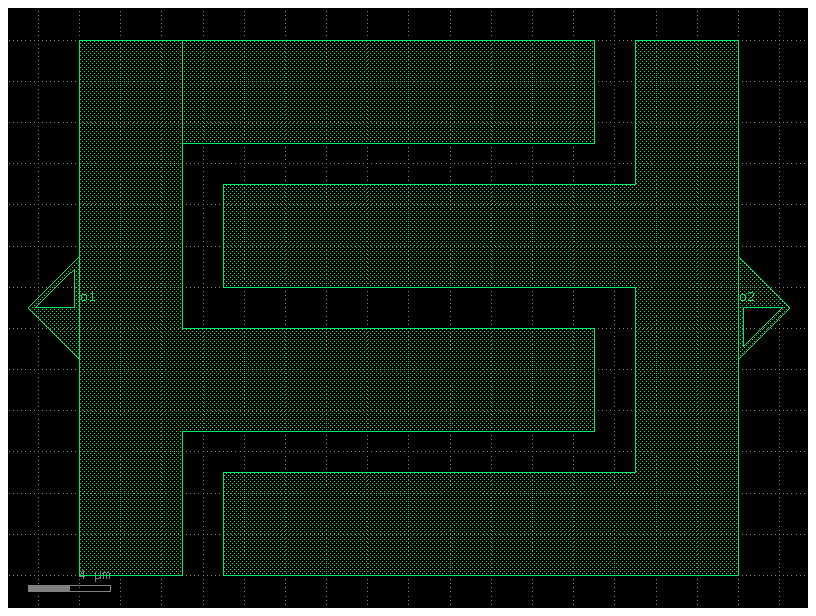

In [16]:
c=gf.components.interdigital_capacitor(
    fingers=4,
    finger_length=20,
    finger_gap=2,
    thickness=5,
    layer='M1'
    )

cc = c.copy() 
cc.flatten()
#If we try meshing directly, without merging the polygons, we get this error in sim.mesh: 
# Error   : Could not create line
# Error   : Curve loop is not closed

c.draw_ports()
c.plot()

In [17]:
cc.ports

["Port(self.name='o1', self.width=5000, trans=r180 *1 0,13, layer=M1 (41/0), port_type=optical)", "Port(self.name='o2', self.width=5000, trans=r0 *1 32,13, layer=M1 (41/0), port_type=optical)"]

In [18]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-idc")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=2.0,
    air_above=200.0,
)

sim.add_port(name="o1", layer="metal1", excited=True)
sim.add_port(name="o2", layer="metal1", excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [19]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 232.0 x 226.0 x 307.6 µm
Nodes:      1,107
Elements:   8,597
Tetrahedra: 6,001
Edge length: 0.40 - 126.00 µm
Quality:    0.524 (min: 0.001)
SICN:       0.563 (all valid)
----------------------------------------
Volumes (4):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - airbox [4]
Surfaces (5):
  - metal1_xy [5]
  - metal1_z [6]
  - P1 [7]
  - P2 [8]
  - Absorbing_boundary [9]
----------------------------------------
Mesh:   ../palace-sim-idc/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:41:22.789 ( 615.933s) [    72D18B781080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:41:22.798 ( 615.943s) [    72D18B781080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 09:41:22.826 ( 615.970s) [    72D18B781080]vt

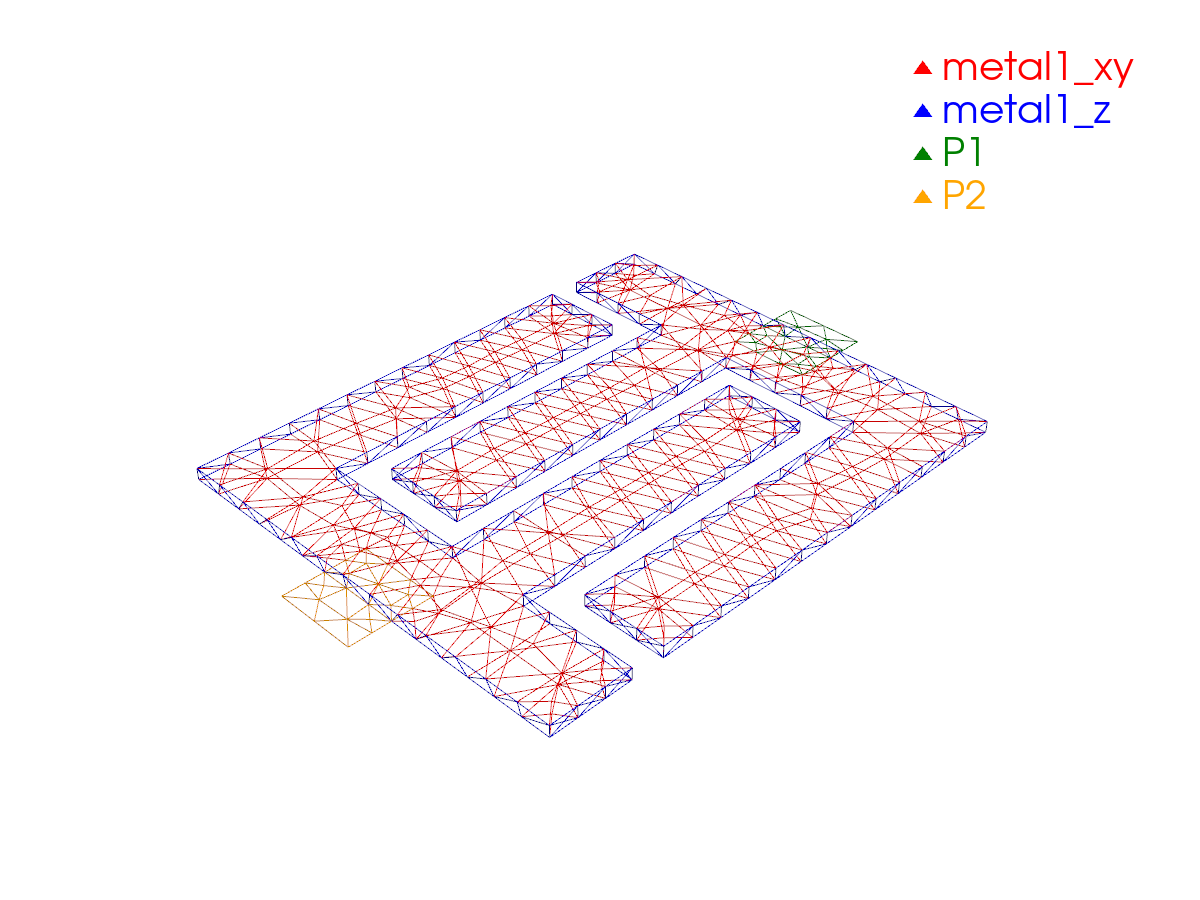

In [20]:
sim.plot_mesh(show_groups=["metal", "P"], interactive=False)